# Quickstart Guide

This tutorial provides a quick introduction to using QCMet for quantum computing benchmarks.

## Running a T1 Measurement
To run a benchmark in QCMet, two main things are required:
1. A benchmark, defining a specific set of circuits to be run on a device together with the analysis instructions
2. An interface to a device which is benchmarked.

Here we consider a simple T1 measurement. T1 is the relaxation time of a qubit - the time it takes for an excited state to decay to the ground state.

The easiest way to run the T1 benchmark on a device (here an emulator with noise) is as follows:

{'success': True, 'T1 (t/t_[1q_gate])': np.float64(5041.365580956495), 'fit': {'popt': array([1.00130568e+00, 5.04136558e+03]), 'pcov': array([[ 1.28255647e-04, -1.23537721e+00],
       [-1.23537721e+00,  2.11534629e+04]])}}


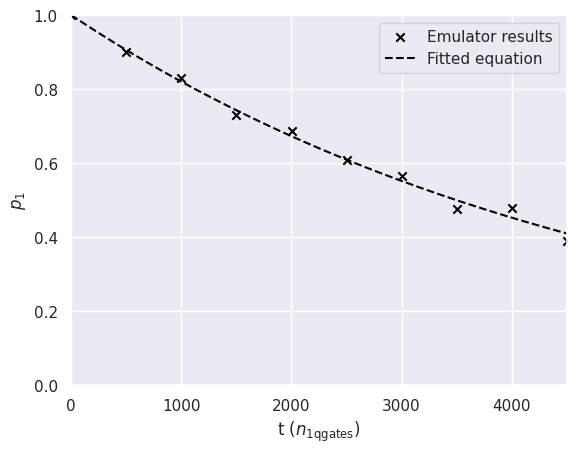

In [3]:
from qcmet import T1
from qcmet.devices import NoisySimulator
device = NoisySimulator()
t1_benchmark = T1()
result = t1_benchmark(device=device, num_shots=1000)
print(result)

## Workflow Summary

Under the hood, benchmarking in QCMet follows the same pattern:

1. **Create a device** (simulator or real hardware)
2. **Initialize the benchmark** with parameters
3. **Generate circuits** using `generate_circuits()`
4. **Run on device** using `run(device, num_shots=...)`
5. **Analyze results** using `analyze()` and `plot()`

This consistent interface makes it easy to swap between different benchmarks and devices.

Steps 3., 4., and 5. are bundled together via the __call__ function of the benchmark, allowing the above workflow.

The extended version of the above looks as follows (giving more fine-grained control over the workflow):

{'success': True, 'T1 (t/t_[1q_gate])': np.float64(5037.61158501775), 'fit': {'popt': array([9.99471683e-01, 5.03761159e+03]), 'pcov': array([[ 1.47857787e-04, -1.42490332e+00],
       [-1.42490332e+00,  2.44154351e+04]])}}


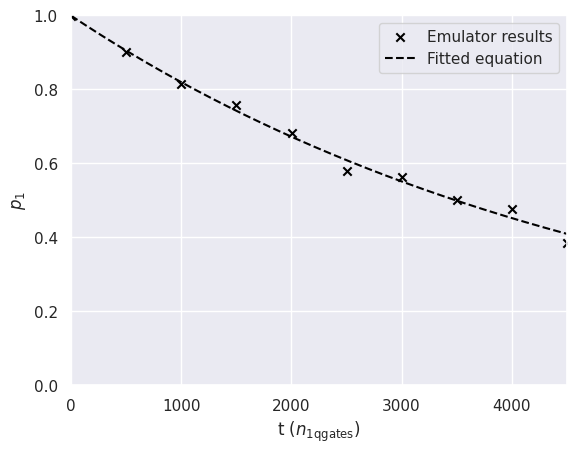

In [6]:
device = NoisySimulator()
t1_benchmark = T1()
t1_benchmark.generate_circuits()
t1_benchmark.run(device, num_shots=1000)
t1_benchmark.analyze()

print(t1_benchmark.result)

# Optional plotting
t1_benchmark.plot();

## Running a Collection of (Different) Benchmarks

Using `BenchmarkCollection`, (different) benchmarks can be conveniently collected together and run in one go. The workflow for `BenchmarkCollection` is the same.

{'T1_qubit0': {'success': True, 'T1 (t/t_[1q_gate])': np.float64(5135.319546014731), 'fit': {'popt': array([1.00406397e+00, 5.13531955e+03]), 'pcov': array([[ 4.63538808e-05, -4.60218624e-01],
       [-4.60218624e-01,  8.08647860e+03]])}}, 'T1_qubit1': {'success': True, 'T1 (t/t_[1q_gate])': np.float64(4929.84554576347), 'fit': {'popt': array([1.00404889e+00, 4.92984555e+03]), 'pcov': array([[ 9.65397941e-05, -8.91066505e-01],
       [-8.91066505e-01,  1.47018583e+04]])}}, 'T2_qubit0': {'success': True, 'T2 (t/t_[1q_gate])': np.float64(3006.4763888036273), 'method': 'hahn', 'fit': {'popt': array([2.45147572e-01, 3.00647639e+03, 7.56375161e-01]), 'pcov': array([[ 6.76609479e-03,  1.14795553e+02, -6.96666209e-03],
       [ 1.14795553e+02,  1.97505744e+06, -1.18662514e+02],
       [-6.96666209e-03, -1.18662514e+02,  7.18292297e-03]])}}, 'T2_qubit1': {'success': True, 'T2 (t/t_[1q_gate])': np.float64(1781145.3340818333), 'method': 'hahn', 'fit': {'popt': array([ 1.14228013e+02,  1.78114533

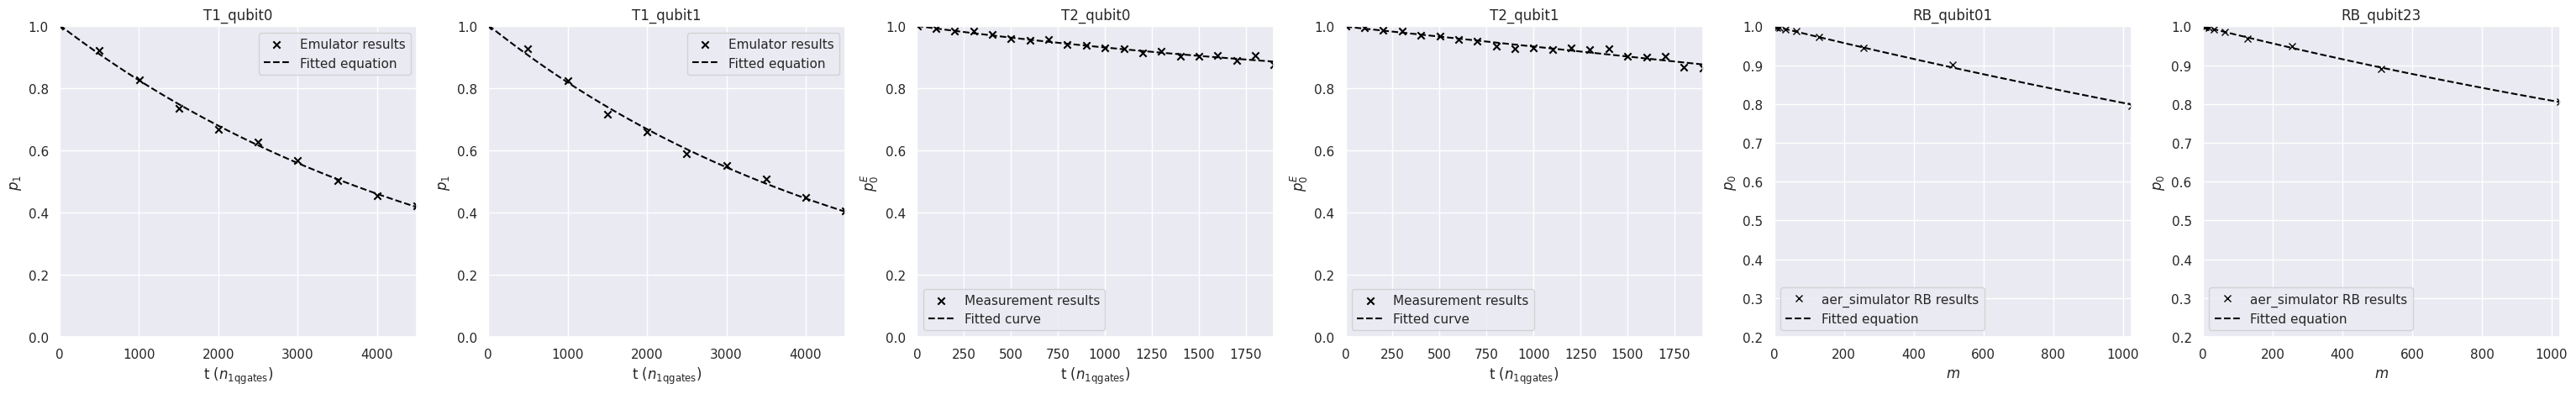

In [12]:
from qcmet import BenchmarkCollection, T2, CliffordRB

t1_benchmark_1 = T1(qubit_index=0)
t1_benchmark_2 = T1(qubit_index=1)
t2_benchmark_1 = T2(qubit_index=0)
t2_benchmark_2 = T2(qubit_index=1)
rb_benchmark_1 = CliffordRB([2 ** n for n in range(1, 11)], qubits=[0, 1])
rb_benchmark_2 = CliffordRB([2 ** n for n in range(1, 11)], qubits=[2, 3])

collection = BenchmarkCollection({"T1_qubit0": t1_benchmark_1, "T1_qubit1": t1_benchmark_2,
                                  "T2_qubit0": t2_benchmark_1, "T2_qubit1": t2_benchmark_2,
                                  "RB_qubit01": rb_benchmark_1, "RB_qubit23": rb_benchmark_2})

# Using the same workflow
collection.generate_circuits()

"""
Now there are two different ways to run the circuits

When passing in a list of shot number for num_shots, all the circuits are submitted
to the device one after the other and each benchmark is run separately with the
corresponding number of shots:
"""
# collection.run(device, num_shots=[1000 for _ in range(6)])

"""
When passing in a single number for num_shots, all circuits are merged and submitted
as one batch
"""
collection.run(device, num_shots=1000)

collection.analyze()
collection.plot()

# Or directly use the call function
# collection(device, num_shots=1000)

print(collection.result)

## Implemented benchmarks

QCMet ships various benchmarking protocols for (digital) quantum computers:

### Qubit Quality Metrics
- **T1**: Relaxation time (energy decay)
- **T2**: Relaxation time (dephasing)
- **Idle Qubit Oscillation Frequency**: Non-Markovian noise induced coherence revivals

### Gate Execution Quality Metrics
- **Clifford RB**: Average gate error rate
- **Interleaved RB**: Specific gate error rate
- **Over/Under Rotation**: Systematic rotation errors
- **Cycle Benchmarking**: Average fidelity of a repeated layer
- **Gate Set Tomography**: Full characterization of process fidelity

### Circuit Execution Quality Metrics
- **Quantum Volume**: Holistic circuit complexity measure
- **Mirrored Circuits**: Target circuit performance benchmark
- **Upper Bound on Variation Distance**: Quantum accreditation protocol

### Well-studied Task Execution Quality Metrics
- **QFT**: Quantum Fourier Transform fidelity
- **VQE**: Energy expectation value reproducibility
- **QScore**: Metric based on using QAOA for a MaxCut problem 
- **Hamiltonian Simulation**: Ability to perform Hamiltonian dynamics
